In [ ]:
import numpy as np, pandas as pd, joblib
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import (f1_score, classification_report, confusion_matrix,
                             cohen_kappa_score, brier_score_loss, precision_recall_fscore_support)
from sklearn.calibration import calibration_curve
from scipy.sparse import hstack
import xgboost as xgb

RS = 42; np.random.seed(RS)
CLASSES = ['low', 'med', 'high']
YT_CAT = {1:'Film&Animation',2:'Autos&Vehicles',10:'Music',15:'Pets&Animals',
          17:'Sports',19:'Travel&Events',20:'Gaming',22:'People&Blogs',23:'Comedy',
          24:'Entertainment',25:'News&Politics',26:'Howto&Style',27:'Education',
          28:'Science&Tech',29:'Nonprofits'}

from google.colab import drive
drive.mount('/content/drive')
DATA_DIR = '/content/drive/My Drive/Data Mining/'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Data Preparation

In [ ]:
df = pd.read_csv(DATA_DIR + 'GB_youtube_trending_data.csv')

df.info()

df[['view_count', 'likes', 'dislikes', 'comment_count']].describe().round(0)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 268791 entries, 0 to 268790
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   video_id           268791 non-null  object
 1   title              268791 non-null  object
 2   publishedAt        268791 non-null  object
 3   channelId          268791 non-null  object
 4   channelTitle       268791 non-null  object
 5   categoryId         268791 non-null  int64 
 6   trending_date      268791 non-null  object
 7   tags               268791 non-null  object
 8   view_count         268791 non-null  int64 
 9   likes              268791 non-null  int64 
 10  dislikes           268791 non-null  int64 
 11  comment_count      268791 non-null  int64 
 12  thumbnail_link     268791 non-null  object
 13  comments_disabled  268791 non-null  bool  
 14  ratings_disabled   268791 non-null  bool  
 15  description        264409 non-null  object
dtypes: bool(2), int64(5)

,view_count,likes,dislikes,comment_count
count,2.687910e+05,268791.0,268791.0,268791.0
mean,2.190558e+06,108098.0,976.0,7983.0
std,6.651493e+06,346532.0,7289.0,59532.0
min,0.000000e+00,0.0,0.0,0.0
25%,3.435020e+05,11095.0,0.0,765.0
50%,7.745050e+05,32137.0,0.0,1978.0
75%,1.844036e+06,87201.0,275.0,5071.0
max,1.406330e+09,15246514.0,865075.0,5987770.0


In [ ]:
df[['title', 'categoryId', 'tags', 'view_count', 'likes', 'comment_count']].head(3)


,title,categoryId,tags,view_count,likes,comment_count
0,I left youtube for a month and THIS is what ha...,24,jacksepticeye|funny|funny meme|memes|jacksepti...,2038853,353790,40228
1,TAXI CAB SLAYER KILLS 'TO KNOW HOW IT FEELS',27,eleanor|neale|eleanor neale|eleanor neale true...,236830,16423,1642
2,Apex Legends | Stories from the Outlands – “Th...,20,Apex Legends|Apex Legends characters|new Apex ...,2381688,146739,16549


In [ ]:
rep = df['video_id'].value_counts()
null_info = df[['title', 'description', 'tags', 'view_count']].isnull().sum()

null_info

,0
title,0
description,4382
tags,0
view_count,0


In [ ]:
rep.describe()

,count
count,47607.000000
mean,5.646039
std,1.747532
min,1.000000
25%,5.000000
50%,6.000000
75%,7.000000
max,17.000000


# Data Cleaning

In [ ]:
#  Remove duplicate and filter zero views
before = len(df)
df = df[df['view_count'] > 0].sort_values('view_count').drop_duplicates('video_id', keep='last').reset_index(drop=True)
print(f'remove duplicates + filter: {before:,} to {len(df):,} unique videos')

# Fix missing text / tags
df['description'] = df['description'].fillna('')

# Replace placeholder [None], strip pipe delimiters and handle missing values
df['tags_clean'] = df['tags'].fillna('').astype(str).replace('[None]', '').str.replace('|', ' ', regex=False)

print('missing after clean:', df[['title', 'description', 'tags_clean']].isnull().sum().sum())

remove duplicates + filter: 268,791 to 47,591 unique videos
missing after clean: 0


# Feature Engineering

In [ ]:
# Combine title and cleaned tags as the base text profile
df['text'] = (df['title'].astype(str) + ' ' + df['tags_clean']).str.strip()
t = df['text']

# Vectorized structural feature calculations
df['len'] = t.str.len()
df['words'] = t.str.split().str.len()

# Vectorized caps calculation (avoids lambda loop over characters)
df['caps'] = t.str.findall(r'[A-Z]').str.len() / (df['len'] + 1)

# Regex checks for special tokens and characters
df['has_num'] = t.str.contains(r'\d', regex=True).astype(int)
df['has_q'] = t.str.contains(r'\?', regex=True).astype(int)
df['has_excl'] = t.str.contains('!', regex=False).astype(int)

# Emoji counter optimized using modern regex range
df['emoji'] = t.str.findall(r'[\U0001F000-\U0001FFFF]').str.len()

# String patterns and frequency tracking
df['hashtags'] = t.str.count('#')
df['mentions'] = t.str.count('@')
df['has_url'] = t.str.contains('http', regex=False).astype(int)

GEN = ['len', 'words', 'caps', 'has_num', 'has_q', 'has_excl', 'emoji', 'hashtags', 'mentions', 'has_url']

# Parse timestamps cleanly
pub = pd.to_datetime(df['publishedAt'], utc=True, errors='coerce')

df['hour'] = pub.dt.hour.fillna(0).astype(int)
df['dow'] = pub.dt.dayofweek.fillna(0).astype(int)
df['weekend'] = (df['dow'] >= 5).astype(int)

# Vectorized tag counter, count pipe characters
df['tag_count'] = df['tags'].fillna('').astype(str).str.count(r'\|') + 1
df.loc[df['tags'].astype(str).isin(['[None]', 'nan', '']), 'tag_count'] = 0

df['no_comments'] = df['comments_disabled'].astype(int)
df['no_ratings'] = df['ratings_disabled'].astype(int)
df['desc_len'] = df['description'].str.len().fillna(0).astype(int)

YT = ['hour', 'dow', 'weekend', 'tag_count', 'no_comments', 'no_ratings', 'desc_len']

# Label Engineering and Prepared Dataset

In [ ]:

# calculate continuous engagement rate target
df['eng'] = (df['likes'] + df['comment_count']) / df['view_count']

indices = np.arange(len(df))
tr_idx, te_idx = train_test_split(indices, test_size=0.2, random_state=RS)

e1, e2 = np.quantile(df['eng'].values[tr_idx], [1/3, 2/3])

# bin the continuous target into discrete tiers (0: Low, 1: Medium, 2: High)
y = np.where(df['eng'].values > e2, 2, np.where(df['eng'].values > e1, 1, 0))

tfidf = TfidfVectorizer(max_features=5000, min_df=5).fit(df['text'].iloc[tr_idx])
Xtxt_tr = tfidf.transform(df['text'].iloc[tr_idx])
Xtxt_te = tfidf.transform(df['text'].iloc[te_idx])

print('final dataset after prepared')
print(f'  videos: {len(df):,}  | train {len(tr_idx):,} / test {len(te_idx):,}')
print(f'  features: {len(tfidf.get_feature_names_out()):,} TF-IDF + {len(GEN+YT)} structural + category')
print(f'  label tiers (train edges {e1:.4f}, {e2:.4f}): {dict(zip(CLASSES, np.bincount(y)))}')

final dataset after prepared
  videos: 47,591  | train 38,072 / test 9,519
  features: 5,000 TF-IDF + 17 structural + category
  label tiers (train edges 0.0297, 0.0552): {'low': np.int64(15852), 'med': np.int64(15857), 'high': np.int64(15882)}


# Exploratory Data Analysis

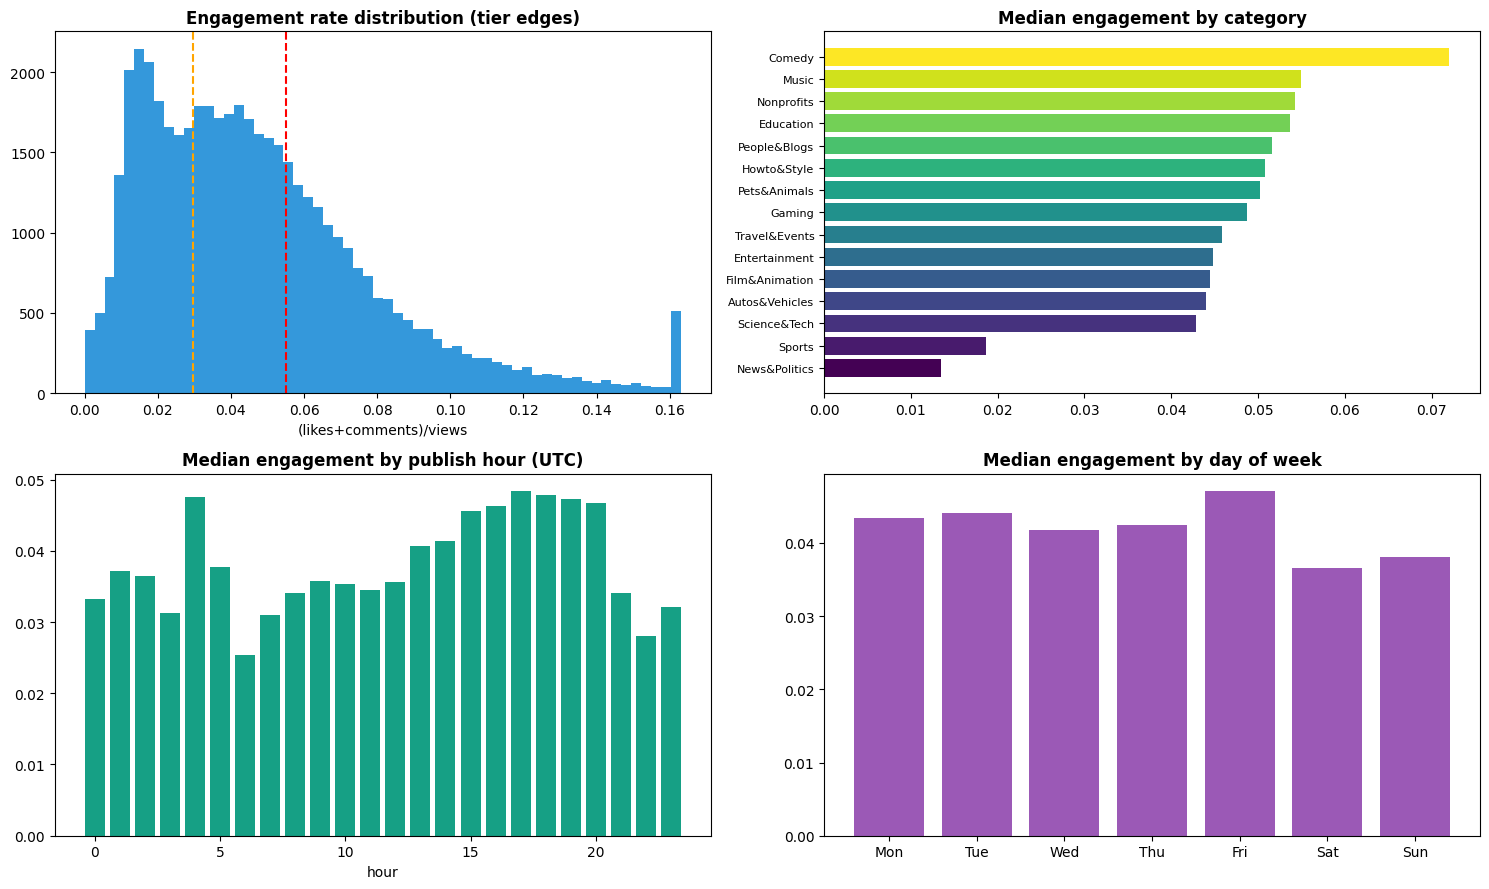

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(15, 9))

# Engagement Distribution Panel
ax[0, 0].hist(np.clip(df['eng'], 0, df['eng'].quantile(0.99)), bins=60, color='#3498DB')
ax[0, 0].axvline(e1, color='orange', ls='--')
ax[0, 0].axvline(e2, color='red', ls='--')
ax[0, 0].set_title('Engagement rate distribution (tier edges)', fontweight='bold')
ax[0, 0].set_xlabel('(likes+comments)/views')

# Category vs Engagement Panel
ce = df.groupby('categoryId')['eng'].median().sort_values()
ax[0, 1].barh(range(len(ce)), ce.values, color=plt.cm.viridis(np.linspace(0, 1, len(ce))))
ax[0, 1].set_yticks(range(len(ce)))
ax[0, 1].set_yticklabels([YT_CAT.get(c, str(c)) for c in ce.index], fontsize=8)
ax[0, 1].set_title('Median engagement by category', fontweight='bold')

# Publish Hour Panel
hh = df.groupby('hour')['eng'].median()
ax[1, 0].bar(hh.index, hh.values, color='#16A085')
ax[1, 0].set_title('Median engagement by publish hour (UTC)', fontweight='bold')
ax[1, 0].set_xlabel('hour')

# Day of Week Panel
dd = df.groupby('dow')['eng'].median()
ax[1, 1].bar(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'][:len(dd)], dd.values, color='#9B59B6')
ax[1, 1].set_title('Median engagement by day of week', fontweight='bold')


plt.tight_layout()
plt.savefig('yt_eda_panels.png', dpi=150, bbox_inches='tight')
plt.show()

# Correlation of structural features with the tier

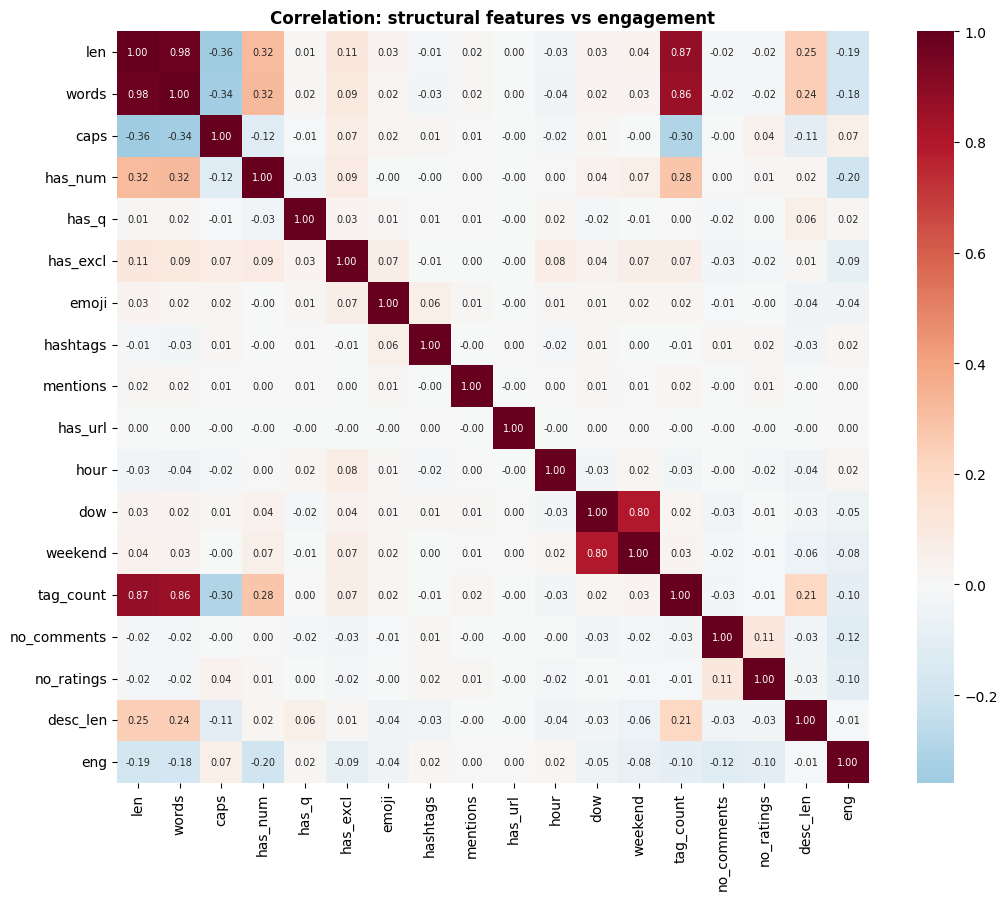

In [ ]:
corr_cols = GEN + YT + ['eng']
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True, ax=ax, annot_kws={'size':7})
ax.set_title('Correlation: structural features vs engagement', fontweight='bold')
plt.tight_layout(); plt.savefig('yt_corr.png', dpi=150, bbox_inches='tight'); plt.show()

#  K-Means clustering (content archetypes)

cluster -> engagement-tier composition (row %):
          low   med  high
cluster                  
0        0.38  0.36  0.26
1        0.34  0.30  0.35
2        0.26  0.33  0.42
3        1.00  0.00  0.00


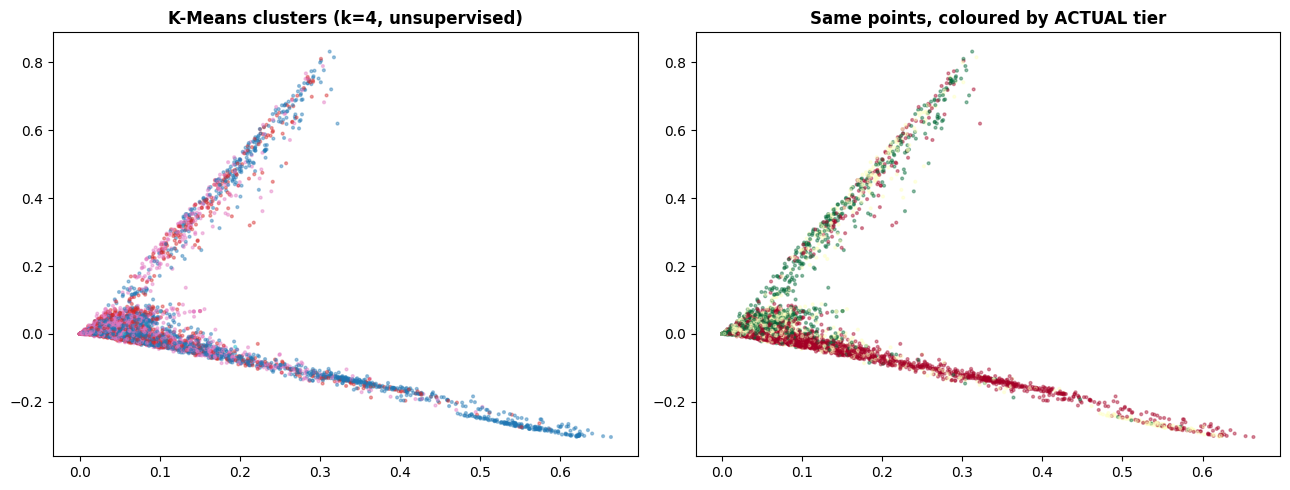

In [ ]:
rng = np.random.RandomState(RS)
samp = rng.choice(len(df), size=min(12000, len(df)), replace=False)

# Compress 5,000 text dimensions to 40 dense SVD components
Xt_s = tfidf.transform(df['text'].iloc[samp])
Zt = TruncatedSVD(n_components=40, random_state=RS).fit_transform(Xt_s)

# Normalize the 17 generic and YouTube structural features
num_s = StandardScaler().fit_transform(df.iloc[samp][GEN + YT].values)

# Merge text and structural features side-by-side
F = np.hstack([Zt, num_s])

clusters = KMeans(n_clusters=4, random_state=RS, n_init=10).fit_predict(F)

ct = pd.crosstab(clusters, y[samp], normalize='index').round(2)
ct.columns = [CLASSES[c] for c in ct.columns]
ct.index.name = 'cluster'

print('cluster -> engagement-tier composition (row %):')
print(ct)


fig, ax = plt.subplots(1, 2, figsize=(13, 5))

ax[0].scatter(Zt[:, 0], Zt[:, 1], c=clusters, cmap='tab10', s=4, alpha=0.4)
ax[0].set_title('K-Means clusters (k=4, unsupervised)', fontweight='bold')

sc = ax[1].scatter(Zt[:, 0], Zt[:, 1], c=y[samp], cmap='RdYlGn', s=4, alpha=0.4)
ax[1].set_title('Same points, coloured by ACTUAL tier', fontweight='bold')

plt.tight_layout()
plt.show()

# Predictive Model Development

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

dummy = DummyClassifier(strategy='stratified', random_state=RS)
dummy.fit(Xtxt_tr, y[tr_idx])

baseline_f1 = f1_score(y[te_idx], dummy.predict(Xtxt_te), average="macro")
print(f'baseline (stratified) Macro F1 = {baseline_f1:.3f} (3 tiers -> ~0.33)\n')


def run(tag, num_cols, use_cat):
    # Scale continuous numerical columns
    sc = StandardScaler().fit(df.iloc[tr_idx][num_cols].values)

    # Store matrix tracks
    ptr = [Xtxt_tr, sc.transform(df.iloc[tr_idx][num_cols].values)]
    pte = [Xtxt_te, sc.transform(df.iloc[te_idx][num_cols].values)]

    ohe = None
    names = list(tfidf.get_feature_names_out()) + list(num_cols)

    # Check for platform categorization strings and apply One-Hot Encoding
    if use_cat:
        ohe = OneHotEncoder(handle_unknown='ignore').fit(
            df.iloc[tr_idx][['categoryId']].astype(str)
        )
        ptr.append(ohe.transform(df.iloc[tr_idx][['categoryId']].astype(str)))
        pte.append(ohe.transform(df.iloc[te_idx][['categoryId']].astype(str)))
        names += ['cat_' + c for c in ohe.categories_[0]]

    # Stack text, numerical structural vectors and one-hot slots into a final CSR matrix
    Xtr, Xte = hstack(ptr).tocsr(), hstack(pte).tocsr()

    base_model = xgb.XGBClassifier(
        objective='multi:softprob',
        num_class=3,
        random_state=RS,
        verbosity=0,
        n_jobs=-1,
    )

    param_distributions = {
        'n_estimators': [100, 200, 300, 400],
        'max_depth': [4, 6, 8, 10],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
    }


    search = RandomizedSearchCV(
        estimator=base_model,
        param_distributions=param_distributions,
        n_iter=5,
        cv=3,
        scoring='f1_macro',
        random_state=RS,
        n_jobs=-1,
    )

    search.fit(Xtr, y[tr_idx])

    m = search.best_estimator_
    print(f'[{tag}] Best Suitable Parameters Found: {search.best_params_}')

    # Execute predictions using the optimized model configuration
    p = m.predict(Xte)
    f1 = f1_score(y[te_idx], p, average='macro')
    print(f'{tag:48s} Optimized Macro F1 = {f1:.4f}\n')

    return dict(
        model=m,
        pred=p,
        proba=m.predict_proba(Xte),
        f1=f1,
        Xte=Xte,
        names=names,
        scaler=sc,
        ohe=ohe,
    )


# Model A: Text data + basic copywriting structural features
A = run('A: text + structure', GEN, False)

# Model B: Text + structural features + YouTube specific channels
B = run('B: + YouTube-specific (category/timing/...)', GEN + YT, True)

# Compute the exact incremental gain of introducing platform features
print(
    f'\n>>> honest unlock delta (B-A) = {B["f1"] - A["f1"]:+.4f} (text already encodes most of it)'
)

model, pred, proba = B['model'], B['pred'], B['proba']

baseline (stratified) Macro F1 = 0.339 (3 tiers -> ~0.33)

[A: text + structure] Best Suitable Parameters Found: {'n_estimators': 300, 'max_depth': 8, 'learning_rate': 0.2}
A: text + structure                              Optimized Macro F1 = 0.6920

[B: + YouTube-specific (category/timing/...)] Best Suitable Parameters Found: {'n_estimators': 300, 'max_depth': 8, 'learning_rate': 0.2}
B: + YouTube-specific (category/timing/...)      Optimized Macro F1 = 0.7043


>>> honest unlock delta (B-A) = +0.0123 (text already encodes most of it)


              precision    recall  f1-score   support

         low       0.84      0.75      0.79      3161
         med       0.62      0.60      0.61      3167
        high       0.67      0.76      0.71      3191

    accuracy                           0.70      9519
   macro avg       0.71      0.70      0.70      9519
weighted avg       0.71      0.70      0.70      9519

Quadratic Weighted Kappa = 0.692  (ordinal agreement; >0.6 substantial)
Exact 70.3% | Off-by-one 25.8% | Catastrophic low<->high 3.89%
HIGH tier -> precision 0.674  recall 0.758



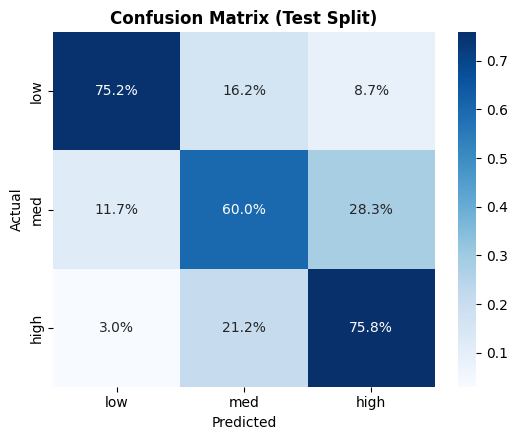

In [14]:
print(classification_report(y[te_idx], pred, target_names=CLASSES, zero_division=0))

# Calculate ordinal agreement using QWK
qwk = cohen_kappa_score(y[te_idx], pred, weights='quadratic')
print(f"Quadratic Weighted Kappa = {qwk:.3f}  (ordinal agreement; >0.6 substantial)")

# Compute absolute error distances
error_distances = np.abs(pred - y[te_idx])
exact_match = (error_distances == 0).mean()
off_by_one = (error_distances == 1).mean()
catastrophic = (error_distances == 2).mean()

print(f"Exact {exact_match:.1%} | Off-by-one {off_by_one:.1%} | Catastrophic low<->high {catastrophic:.2%}")

# Isolate specific performance metrics for the HIGH viral tier
prc, rcl, _, _ = precision_recall_fscore_support(y[te_idx], pred, labels=[2], zero_division=0)
print(f"HIGH tier -> precision {prc[0]:.3f}  recall {rcl[0]:.3f}\n")

fig, ax = plt.subplots(figsize=(5.5, 4.5))

cm = confusion_matrix(y[te_idx], pred)
normalized_cm = cm / cm.sum(axis=1, keepdims=True)

sns.heatmap(
    normalized_cm,
    annot=True,
    fmt='.1%',
    cmap='Blues',
    xticklabels=CLASSES,
    yticklabels=CLASSES,
    ax=ax,
    cbar=True
)

ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix (Test Split)', fontweight='bold')

plt.tight_layout()
plt.show()

Confidence Threshold Summary Metrics:
 tau  coverage  precision  recall
 0.4     0.406      0.659   0.797
 0.5     0.294      0.754   0.662
 0.6     0.195      0.830   0.483
 0.7     0.131      0.888   0.346
 0.8     0.079      0.931   0.219

>>> trigger P(high) >= 0.7: precision 89%, fires on 13% of uploads


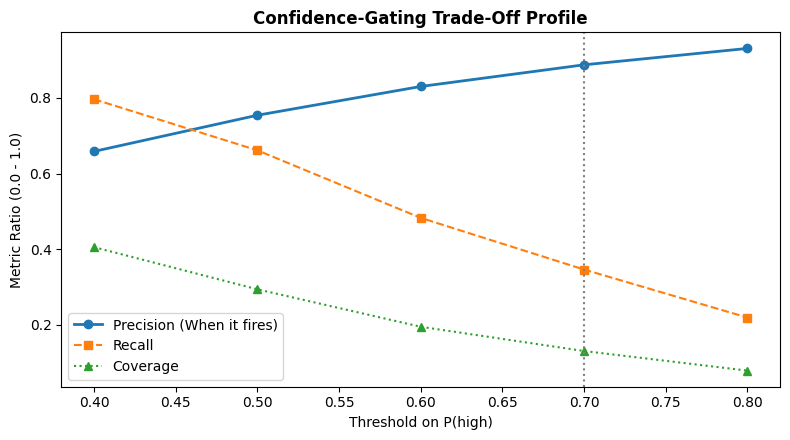

In [15]:
# Extract the raw, model-predicted probability for the high-engagement tier
phigh = proba[:, 2]
yhigh = (y[te_idx] == 2).astype(int)

rows = []
# Sweep through confidence threshold cuts (tau)
for tau in [0.40, 0.50, 0.60, 0.70, 0.80]:
    flag = phigh >= tau
    if flag.sum() == 0:
        continue

    rows.append(dict(
        tau=tau,
        coverage=flag.mean(),
        precision=yhigh[flag].mean(),
        recall=(flag & (yhigh == 1)).sum() / max(yhigh.sum(), 1)
    ))

gate = pd.DataFrame(rows)
print("Confidence Threshold Summary Metrics:")
print(gate.round(3).to_string(index=False))


TAU = 0.70
fl = phigh >= TAU
print(f'\n>>> trigger P(high) >= {TAU}: precision {yhigh[fl].mean():.0%}, fires on {fl.mean():.0%} of uploads')

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.plot(gate['tau'], gate['precision'], 'o-', label='Precision (When it fires)', linewidth=2)
ax.plot(gate['tau'], gate['recall'], 's--', label='Recall')
ax.plot(gate['tau'], gate['coverage'], '^:', label='Coverage')

ax.axvline(TAU, color='gray', ls=':')
ax.set_xlabel('Threshold on P(high)')
ax.set_ylabel('Metric Ratio (0.0 - 1.0)')
ax.legend()
ax.set_title('Confidence-Gating Trade-Off Profile', fontweight='bold')

plt.tight_layout()
plt.show()

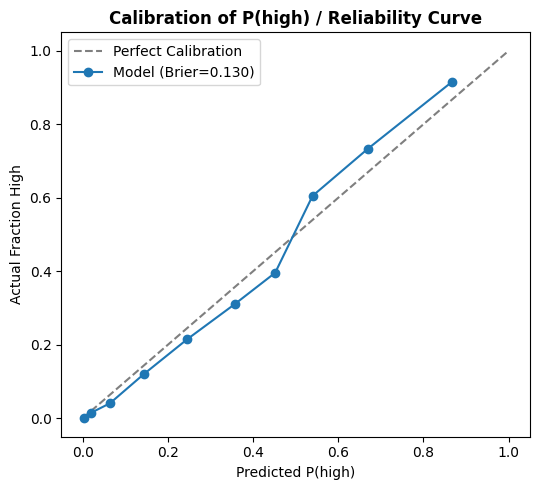

In [16]:
# Calculate the empirical probability matching using quantile-based binning
frac_pos, mean_pred = calibration_curve(yhigh, phigh, n_bins=10, strategy='quantile')

# Calculate the Brier Score Loss to measure total mean squared error
brier = brier_score_loss(yhigh, phigh)

fig, ax = plt.subplots(figsize=(5.5, 5))

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect Calibration')
ax.plot(mean_pred, frac_pos, 'o-', label=f'Model (Brier={brier:.3f})')

ax.set_xlabel('Predicted P(high)')
ax.set_ylabel('Actual Fraction High')
ax.set_title('Calibration of P(high) / Reliability Curve', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()

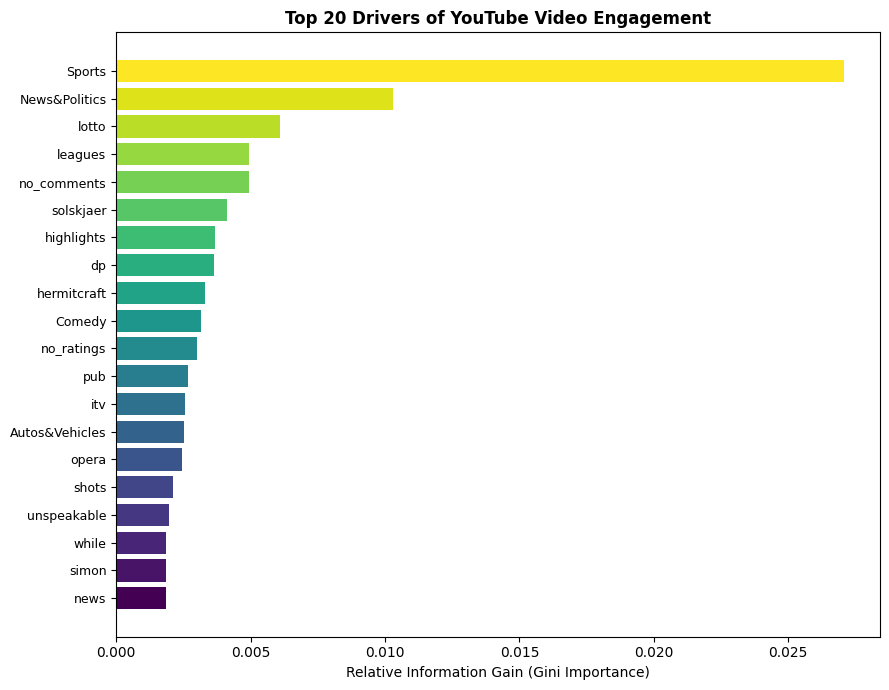

In [17]:
# Extract the raw structural Gini importance scores from the winning XGBoost model
imp = model.feature_importances_

# Sort feature indices in descending order and slice the top 20 drivers
top = np.argsort(imp)[::-1][:20]
names = B['names']

disp = [YT_CAT.get(int(names[i][4:]), names[i]) if names[i].startswith('cat_') else names[i] for i in top]


fig, ax = plt.subplots(figsize=(9, 7))

ax.barh(
    range(20),
    imp[top][::-1],
    color=plt.cm.viridis(np.linspace(0, 1, 20))
)

ax.set_yticks(range(20))
ax.set_yticklabels(disp[::-1], fontsize=9)
ax.set_title('Top 20 Drivers of YouTube Video Engagement', fontweight='bold')
ax.set_xlabel('Relative Information Gain (Gini Importance)')

plt.tight_layout()
plt.show()

In [18]:
import joblib

artifacts = dict(
    model=model,                  # The optimized, winning XGBoost model instance
    tfidf=tfidf,                  # The fitted text vocabulary processor
    scaler=B['scaler'],            # The numerical feature standardization scaler
    ohe=B['ohe'],                  # The categorical platform encoder
    num_cols=GEN + YT,             # The strict order sequence of numerical features
    classes=CLASSES,              # Human-readable labels (Low, Med, High)
    feature_names=B['names'],      # Decoded feature names for SHAP explanations
    tier_edges=[float(e1), float(e2)],  # Boundaries separating performance tiers
    tau=TAU,                      # The 70% production confidence gate rule
    version='yt-deep-1.0'         # Pipeline release version tag
)

joblib.dump(artifacts, 'youtube_model.joblib', compress=3)

['youtube_model.joblib']